In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib
# adjust this to your repo root if different
repo_root = pathlib.Path('/home/ubuntu/qecsim-1').resolve()
sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: C:\home\ubuntu\qecsim-1


In [3]:
from qecsim.tools.qem_estimator.calc_ptm import calc_ptm
from qecsim.codes.lattice_surgery.builder import surgery_circuit
from qecsim.tools.qem_estimator.logical_estimator import logical_estimator
from qecsim.codes.surface_code_rotated.builder import rotated_surface_code

In [4]:
noise = 0.01
distance = 3

###############
# Diag Circuits
###############
"""
For the Diagonal we can use pauli frames -> Only need 3 isntead of 6
"""
c_0_z = rotated_surface_code(distance= distance, 
                             rounds= distance, 
                             log_obs= "Z", 
                             state_init= "0", 
                             noise_after_clifford_depol= noise, 
                             noise_after_reset= noise, 
                             noise_depol_data_init= noise, 
                             noise_measure_flip= noise)
c_p_x = rotated_surface_code(distance= distance,
                            rounds= distance, 
                            log_obs= "X", 
                            state_init= "+", 
                            noise_after_clifford_depol= noise, 
                            noise_after_reset= noise, 
                            noise_depol_data_init= noise, 
                            noise_measure_flip= noise)
c_pi_y = rotated_surface_code(distance= distance, 
                           rounds= distance, 
                           log_obs= "Y", 
                           state_init= "+i", 
                           noise_after_clifford_depol= noise, 
                           noise_after_reset= noise, 
                           noise_depol_data_init= noise, 
                           noise_measure_flip= noise)

###################
# Off-Diag Circuits
###################
"""
We need full physical (Noiseless) Implementation of the logical state we want to initilize
-> Rec pos stay the same so can be reused (Measurement indexes wont change -> No new measurements)

We have 6 non diag entries with either needign 2 circs -> 12 circs in total
"""
c_0_x, rec_pos_log_x = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "X", 
                                            state_init= "0", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_1_x, rec_pos_log_x = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "X", 
                                            state_init= "1", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_pi_x, rec_pos_log_x_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "X", 
                                                state_init= "+i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_mi_x, rec_pos_log_x_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "X", 
                                                state_init= "-i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_p_z, rec_pos_log_z = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "Z", 
                                            state_init= "+", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_m_z, rec_pos_log_z = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "Z", 
                                            state_init= "-", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_pi_z, rec_pos_log_z_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "Z", 
                                                state_init= "+i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_mi_z, rec_pos_log_z_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "Z", 
                                                state_init= "-i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_0_y, rec_pos_log_y0 = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "0", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_1_y, rec_pos_log_y0 = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "1", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_p_y, rec_pos_log_yp = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "+", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_m_y, rec_pos_log_yp = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "-", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)

In [5]:
c_m_y

stim.Circuit('''
    QUBIT_COORDS(0, 2) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(1, 3) 2
    QUBIT_COORDS(1, 5) 3
    QUBIT_COORDS(2, 2) 4
    QUBIT_COORDS(2, 4) 5
    QUBIT_COORDS(2, 6) 6
    QUBIT_COORDS(3, 1) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(3, 5) 9
    QUBIT_COORDS(4, 0) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(4, 4) 12
    QUBIT_COORDS(5, 1) 13
    QUBIT_COORDS(5, 3) 14
    QUBIT_COORDS(5, 5) 15
    QUBIT_COORDS(6, 4) 16
    RX 1 2 3 7 8 9 13 14 15
    Z 2 8 14
    OBSERVABLE_INCLUDE(0) X2 X3 Y1 Z7 Z13
    TICK
    R 4 12 6 10 5 11 0 16
    TICK
    H 4 12 6 10
    TICK
    CX 4 7 8 5 13 11 12 14 1 0 6 9
    TICK
    CX 4 1 9 5 14 11 12 8 2 0 6 3
    TICK
    CX 4 8 2 5 7 11 12 15 14 16 10 13
    TICK
    CX 4 2 3 5 8 11 12 9 15 16 10 7
    TICK
    H 4 12 6 10
    TICK
    M 4 12 6 10 5 11 0 16
    TICK
    REPEAT 2 {
        R 4 12 6 10 5 11 0 16
        TICK
        DEPOLARIZE1(0.01) 1 2 3 7 8 9 13 14 15
        H 4 12 6 10
        TICK
        CX 4 7 8 5 13 

In [6]:
#################
# Calculating PTM
#################

PTM= calc_ptm(circuit_0_z= c_0_z,
              circuit_p_z= c_p_z,
              circuit_m_z= c_m_z,
              circuit_pi_z= c_pi_z,
              circuit_mi_z= c_mi_z,
              circuit_0_x= c_0_x,
              circuit_1_x= c_1_x, 
              circuit_p_x= c_p_x,
              circuit_pi_x= c_pi_x,
              circuit_mi_x= c_mi_x,
              circuit_pi_y= c_pi_y,
              circuit_0_y= c_0_y, 
              circuit_1_y= c_1_y,
              circuit_p_y= c_p_y,
              circuit_m_y= c_m_y, 
              rec_pos_log_y01= rec_pos_log_y0, 
              rec_pos_log_ypm= rec_pos_log_yp,
              rec_pos_log_x = rec_pos_log_x, 
              rec_pos_log_z = rec_pos_log_z,
              rec_pos_log_x_pmi= rec_pos_log_x_pi, 
              rec_pos_log_z_pmi= rec_pos_log_z_pi,
              samples = 10_000)
PTM

array([[ 9.236e-01, -5.000e-03,  4.200e-03],
       [-1.000e-04,  9.976e-01,  1.600e-03],
       [-1.000e-03, -1.000e-03,  9.198e-01]])

In [7]:
# For testing create Diagonal PTM
import numpy as np

def diag_ptm(ptm: np.ndarray) -> np.ndarray:

    ptm_diag = [
            [ptm[0,0], 0.0, 0.0], 
            [0.0, ptm[0,0], 0.0], 
            [0.0, 0.0, ptm[0,0]]]

    return(np.array(ptm_diag))

In [8]:
#################################
# Test Estimator on Memory Rounds
#################################
memory_z = c_0_z
memory_x = c_p_x
memory_y = c_pi_y

ptm_diag = diag_ptm(PTM)

fll_sol = logical_estimator(ptm= PTM,
                  ptm_circuit_x= memory_x,
                  ptm_circuit_y= memory_y,
                  ptm_circuit_z= memory_z,
                  logical_obs = "X", 
                  frame_flip= False, 
                  shots = 80_000)

diag_sol = logical_estimator(ptm= ptm_diag,
                  ptm_circuit_x= memory_x,
                  ptm_circuit_y= memory_y,
                  ptm_circuit_z= memory_z,
                  logical_obs = "X", 
                  frame_flip= False, 
                  shots = 80_000)

print(fll_sol, diag_sol)

(np.float64(0.9993442529676758), np.float64(0.001572791204846706)) (np.float64(1.0006766998700736), np.float64(0.0014617217040648694))


In [12]:
distance = 3
noise = 0.1

########
# ONLY X
########

circ_IX_IX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="X -> X",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_XI_XX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="X -> XX",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_XX_XI_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="XX -> X",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

########
# ONLY Y
########



########
# ONLY Z
########

circ_ZI_ZI_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="Z -> Z",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_IZ_ZZ_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="Z -> ZZ",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_ZZ_IZ_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="ZZ -> Z",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

#############
# Mixed Terms
#############

circ_ZX_ZX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="Z0", 
                            flow_observable="ZX -> ZX",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)


In [11]:
surgery_circuit(distance=3, target_state_init="Z1", control_state_init="Y-", flow_observable="YZ -> XY").diagram("detslice-with-ops-svg")

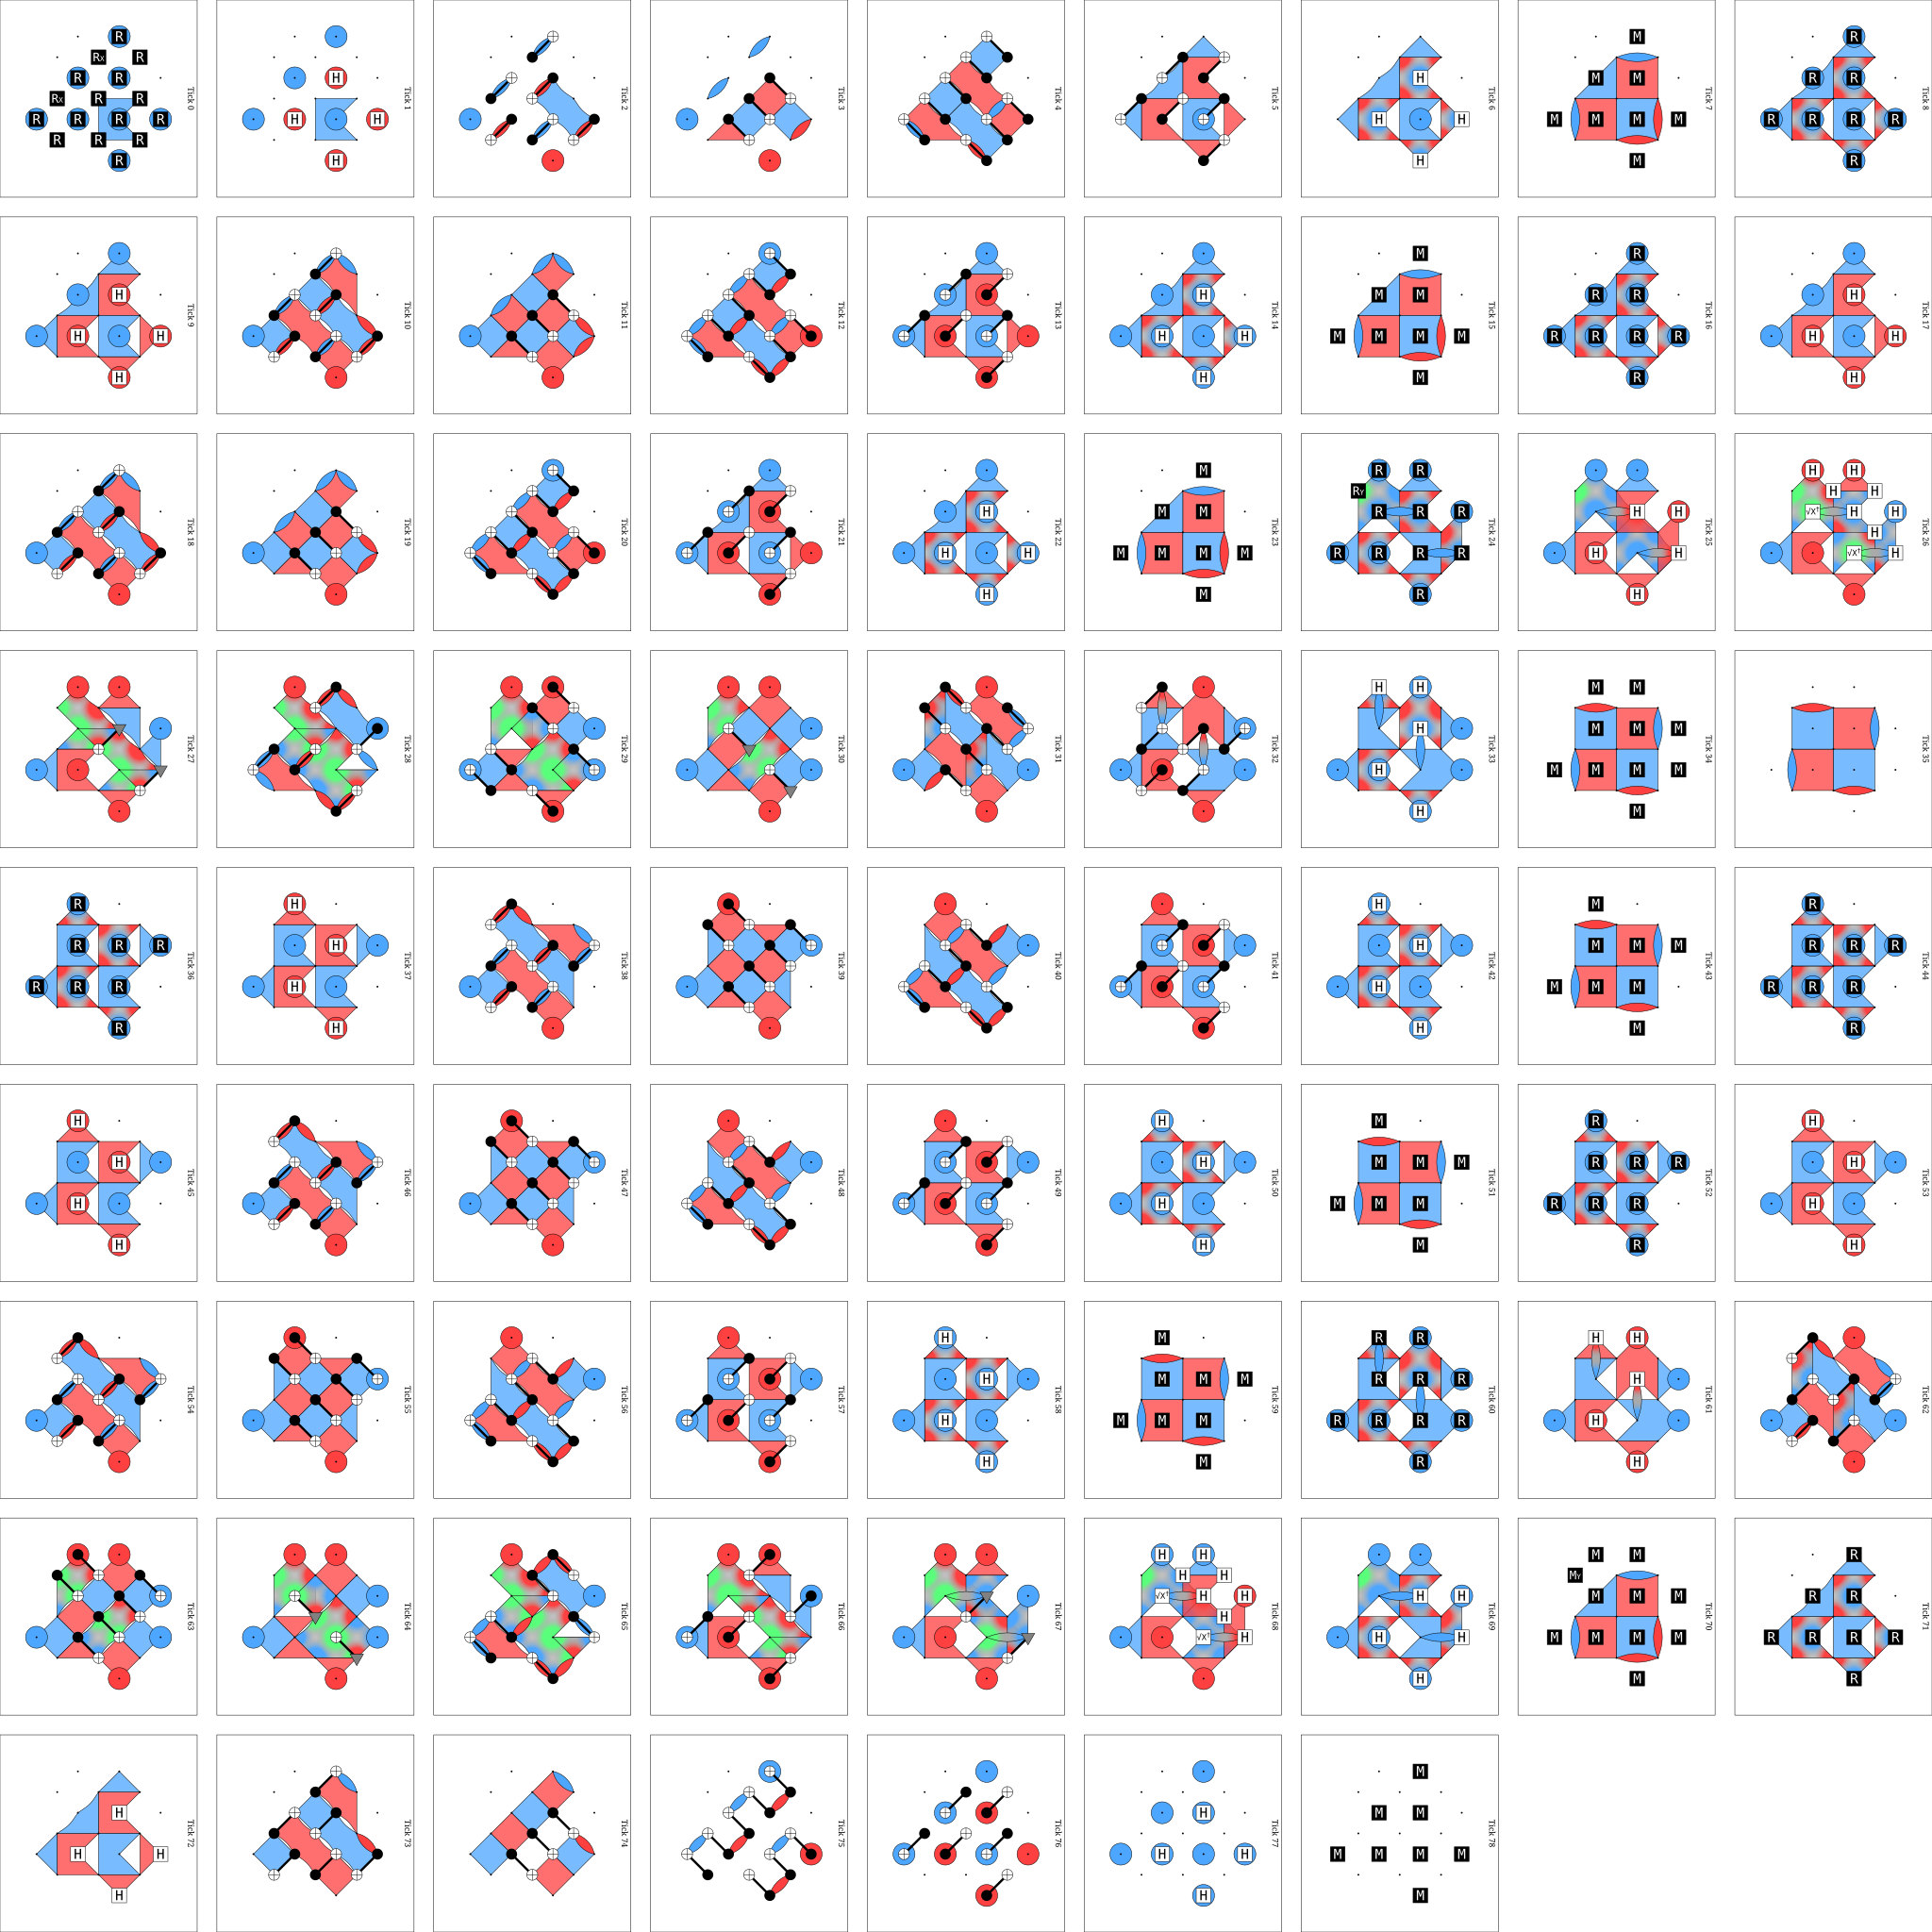

In [13]:
rotated_surface_code(distance= distance, 
                           rounds= distance, 
                           log_obs= "Y", 
                           state_init= "+i"
                           ).diagram("detslice-with-ops-svg")

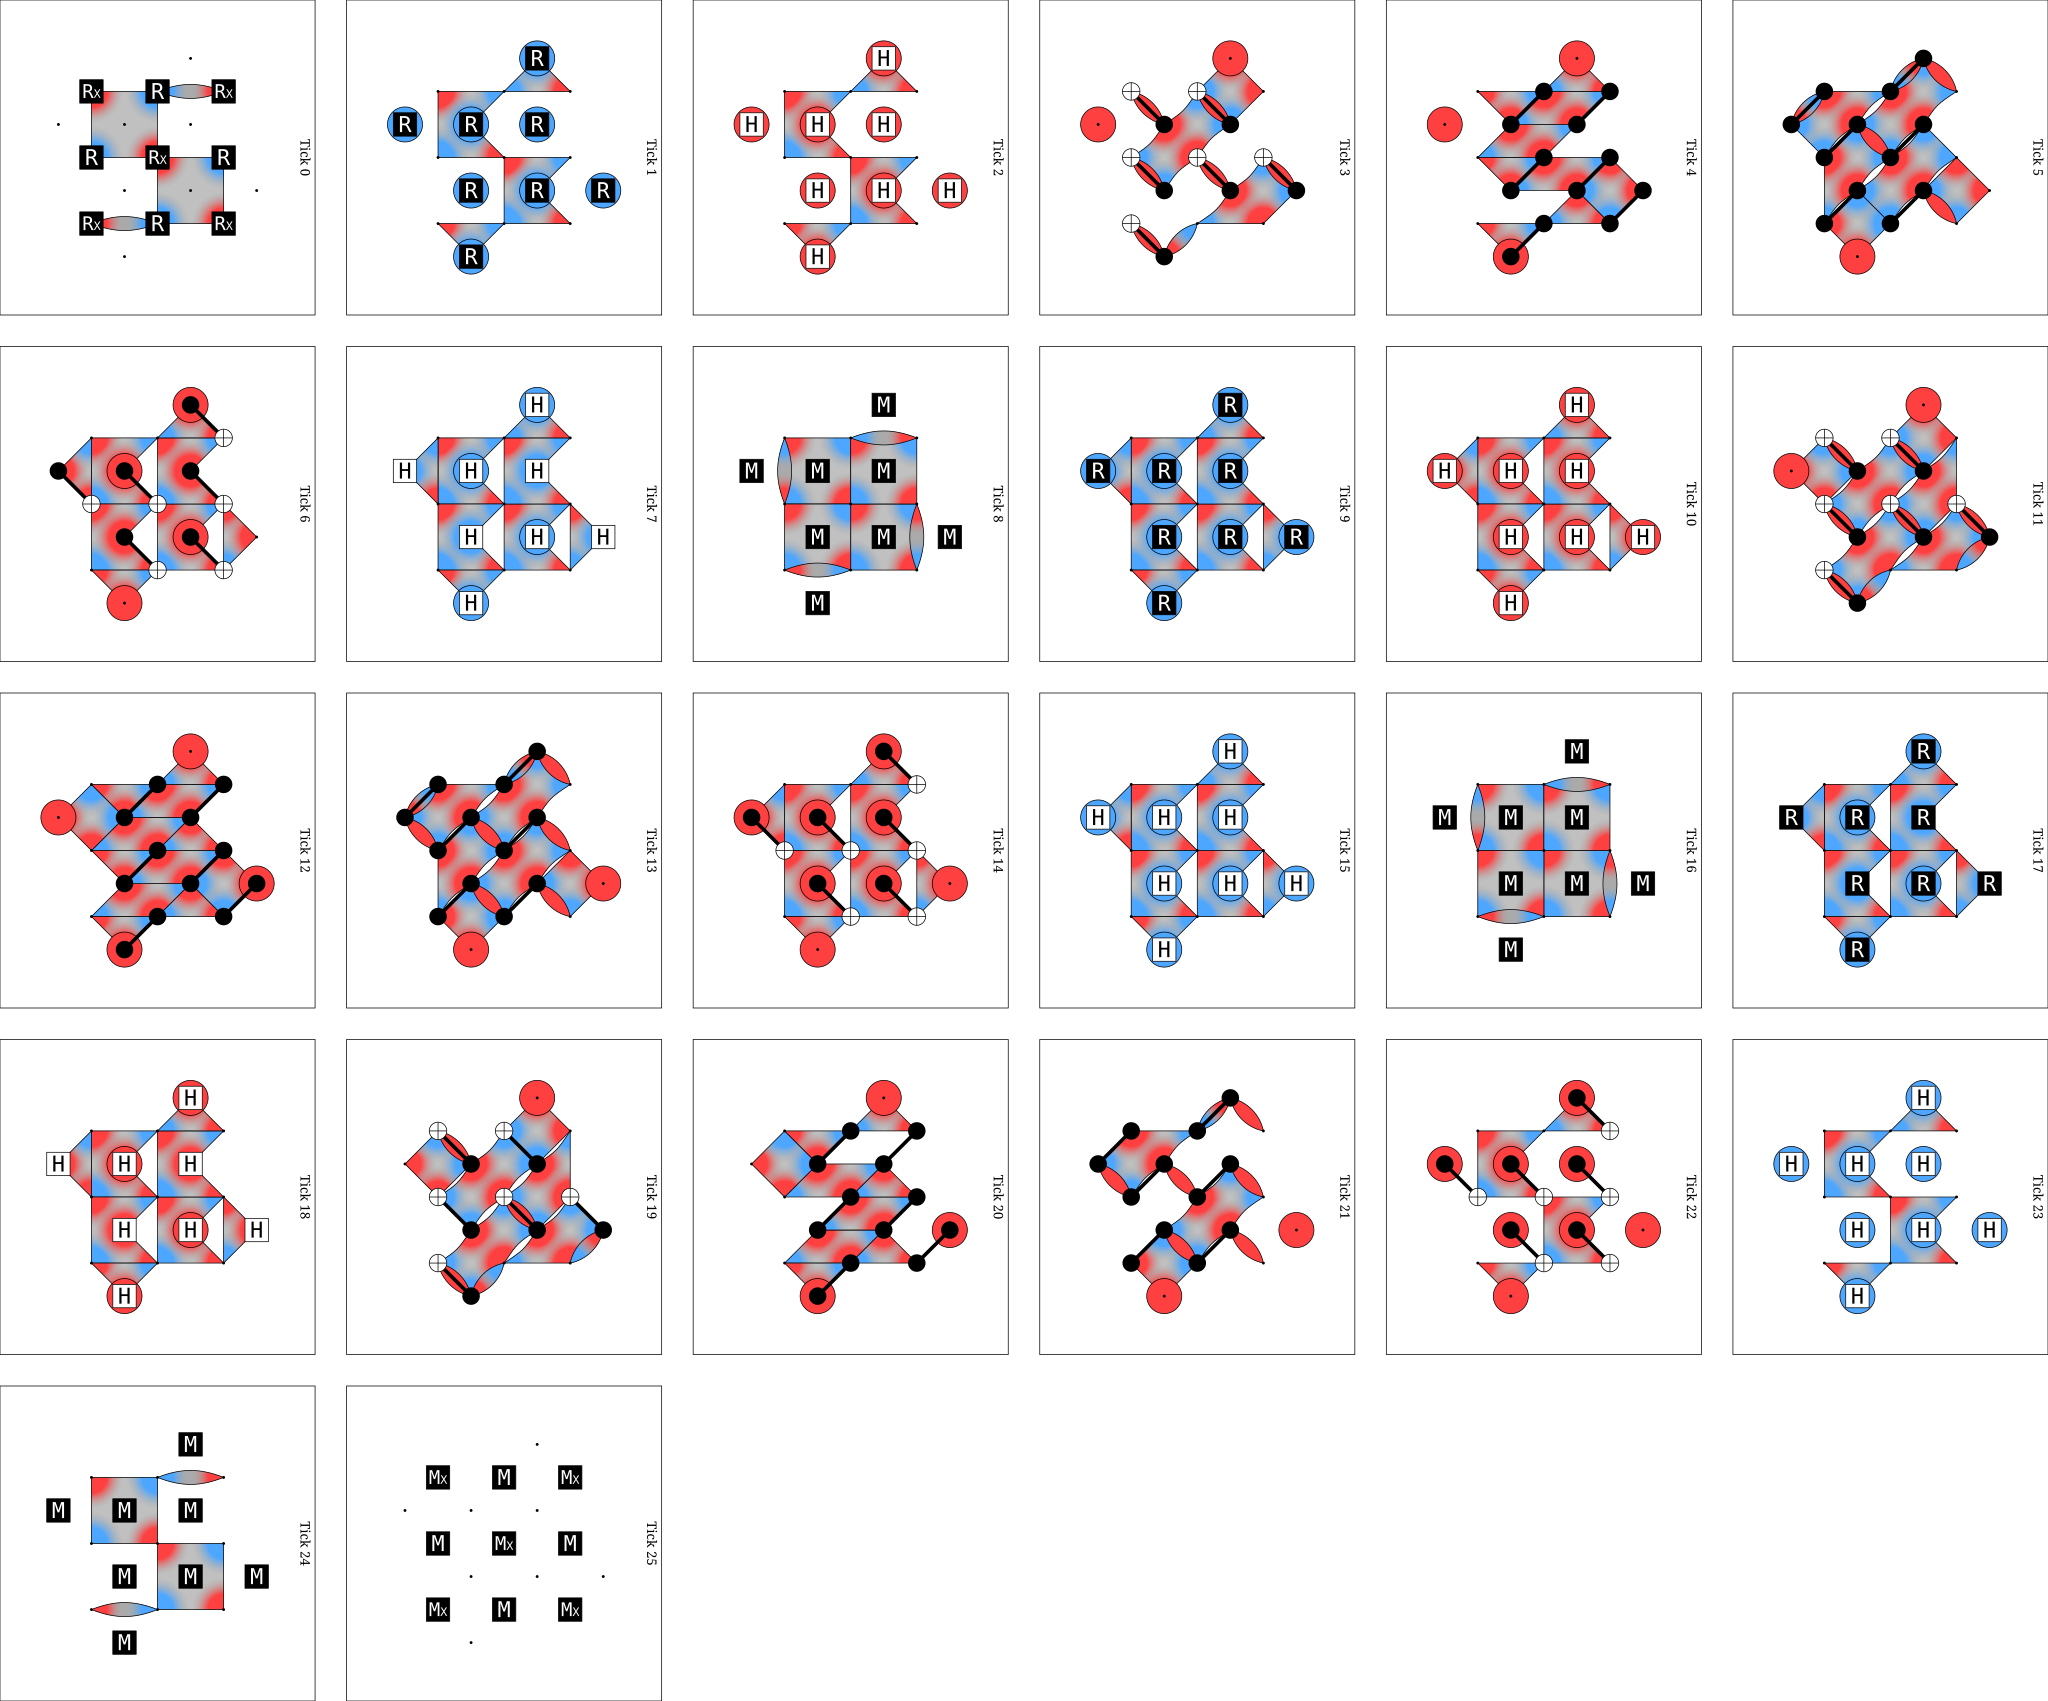

In [ ]:
import stim
from qecsim.core.add_noise import CircuitNoise, BiasNoise
from qecsim.codes.xzzx.builder import xzzx_code

noise = 0.3

test_xzzx = xzzx_code(distance=3,
                      rounds=3,
                      state_init="Ver",
                      )

test_xzzx_2 = xzzx_code(distance=3,
                      rounds=3,
                      state_init="Ver",
                      before_round_p_xyz= [0.1, 0.2, 0.3],
                      noise_bias= [1,0,0],
                      after_c_pauli_channel_prob= noise,
                      after_c_depol_prob= noise,
                      after_r_flip= noise,
                      before_m_flip_prob= noise,
                      before_round_depol= noise
                      )

test_xzzx.diagram("detslice-with-ops-svg")